# Conjugate Priors for Cybersecurity Anomaly Detection

**Demonstrating Dirichlet-Categorical conjugate priors on the LANL authentication dataset**

This notebook accompanies the article "Understanding Conjugate Priors Through Real-World Data" and provides a complete implementation of Bayesian anomaly detection using conjugate priors.

## Dataset
- **LANL Comprehensive Multi-Source Cyber-Security Events Dataset**
- 1.648 billion authentication events over 58 days
- 749 red team attack events
- Available at: https://csr.lanl.gov/data/cyber1/

## What this notebook demonstrates:
1. **Dirichlet-Categorical conjugate priors** for categorical data
2. **Online Bayesian learning** with streaming data
3. **Temporal train/test splits** for realistic evaluation
4. **Computer-window labeling** strategy
5. **Performance evaluation** with ROC/PR curves


## Setup and Data Preparation

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import gzip
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📦 All libraries imported successfully!")

📦 All libraries imported successfully!


In [3]:
# Mount Google Drive to access LANL dataset
from google.colab import drive
drive.mount('/content/drive')

# Set data paths - UPDATE THESE PATHS to match your Google Drive structure
AUTH_FILE = '/content/drive/MyDrive/Lanl_login_data/auth.txt.gz'
REDTEAM_FILE = '/content/drive/MyDrive/Lanl_login_data/redteam.txt.gz'

print("💾 Google Drive mounted successfully!")
print(f"📁 Authentication data: {AUTH_FILE}")
print(f"📁 Red team data: {REDTEAM_FILE}")

Mounted at /content/drive
💾 Google Drive mounted successfully!
📁 Authentication data: /content/drive/MyDrive/Lanl_login_data/auth.txt.gz
📁 Red team data: /content/drive/MyDrive/Lanl_login_data/redteam.txt.gz


## Mathematical Foundation: Dirichlet-Categorical Conjugate Priors

### The Model

For each computer $c$, we model authentication patterns using:

**Prior:** $\boldsymbol{\theta}^{(c)} \sim \text{Dir}(\alpha, \alpha, \ldots, \alpha)$

**Likelihood:** $\text{auth\_type} | \text{computer } c \sim \text{Categorical}(\boldsymbol{\theta}^{(c)})$

**Posterior:** $\boldsymbol{\theta}^{(c)} | \text{data} \sim \text{Dir}(\alpha + \boldsymbol{n}^{(c)})$

### The Update Rule

The beautiful simplicity of conjugate priors:

$$P(\text{category } k | \text{data}) = \frac{\alpha + n_k}{\alpha_0 + N}$$

**Anomaly Score:** $-\log P(\text{category } k | \text{data})$

### Why α = 1 (Uniform Prior)?

- **No bias:** Equal initial belief for all authentication types
- **Minimal influence:** Lets data drive the learning
- **Smooth handling:** Prevents zero probabilities for unseen categories

## Implementation

In [4]:
class DirichletCategorical:
    """
    Bayesian categorical model using Dirichlet-Categorical conjugate priors.
    
    This implements the mathematical framework:
    θ ~ Dir(α)
    x | θ ~ Categorical(θ)  
    θ | data ~ Dir(α + counts)
    """
    
    def __init__(self, alpha_prior=1.0):
        """
        Initialize with symmetric Dirichlet prior.
        
        Parameters:
        -----------
        alpha_prior : float
            Prior pseudo-count for each category (α parameter)
        """
        self.counts = defaultdict(int)  # Observed category counts n_k
        self.alpha_prior = alpha_prior  # Prior parameter α
        self.total = 0                  # Total observations N
        
    def update(self, observations):
        """
        Online Bayesian update: increment sufficient statistics.
        
        This implements the conjugate prior update:
        Dir(α) → Dir(α + n) where n are new counts
        """
        for obs in observations:
            self.counts[obs] += 1
            self.total += 1
    
    def anomaly_score(self, category):
        """
        Compute surprisal: -log(probability)
        
        Formula: -log((α + n_k) / (α_0 + N))
        Higher score = more anomalous
        """
        # Posterior parameters
        alpha_posterior = self.counts.get(category, 0) + self.alpha_prior
        total_alpha = self.total + len(self.counts) * self.alpha_prior
        
        # For unseen categories, add α to denominator
        if category not in self.counts:
            total_alpha += self.alpha_prior
        
        # Posterior predictive probability
        probability = alpha_posterior / total_alpha
        
        # Anomaly score
        return -np.log(probability + 1e-10)  # Numerical stability
    
    def get_statistics(self):
        """Get model statistics for analysis."""
        return {
            'total_observations': self.total,
            'unique_categories': len(self.counts),
            'most_common': max(self.counts.items(), key=lambda x: x[1]) if self.counts else None,
            'entropy': self._compute_entropy()
        }
    
    def _compute_entropy(self):
        """Compute the entropy of the learned distribution."""
        if not self.counts:
            return 0.0
            
        total = self.total + len(self.counts) * self.alpha_prior
        entropy = 0.0
        
        for count in self.counts.values():
            prob = (count + self.alpha_prior) / total
            entropy -= prob * np.log(prob + 1e-10)
            
        return entropy

print("✅ DirichletCategorical class defined")

✅ DirichletCategorical class defined


In [5]:
class EnterpriseAuthDetector:
    """
    Multi-signal Bayesian anomaly detector for enterprise authentication events.
    
    Models two categorical distributions per computer:
    1. Authentication type patterns
    2. Source user access patterns
    """
    
    def __init__(self, alpha_prior=1.0):
        """
        Initialize detector with specified prior strength.
        
        Parameters:
        -----------
        alpha_prior : float
            Dirichlet prior parameter (α = 1.0 for uniform prior)
        """
        self.computer_models = {}  # Per-computer behavioral models
        
        # Global models for fallback (new computers)
        self.global_models = {
            'auth_types': DirichletCategorical(alpha_prior),
            'users': DirichletCategorical(alpha_prior)
        }
        
        self.alpha_prior = alpha_prior
        self.training_stats = {}
        
    def train_on_events(self, events_iterator, max_timestamp=None):
        """
        Train the detector on historical authentication events.
        
        This implements online Bayesian learning:
        - Each event updates relevant Dirichlet posterior
        - No batch processing or optimization required
        """
        events_processed = 0
        computers_seen = set()
        
        print("🧠 Training Bayesian models on authentication patterns...")
        
        for event in tqdm(events_iterator, desc="Learning normal behaviors"):
            # Stop at temporal boundary if specified
            if max_timestamp and event['timestamp'] >= max_timestamp:
                print(f"\n⏰ Stopped training at timestamp {event['timestamp']}")
                break
                
            # Only learn from successful authentications
            if event['success'] != 'Success':
                continue
                
            computer = event['dest_computer']
            auth_type = event['auth_type']
            user = event['source_user']
            
            # Initialize per-computer models if not seen before
            if computer not in self.computer_models:
                self.computer_models[computer] = {
                    'auth_types': DirichletCategorical(self.alpha_prior),
                    'users': DirichletCategorical(self.alpha_prior)
                }
                computers_seen.add(computer)
            
            # Update per-computer models
            self.computer_models[computer]['auth_types'].update([auth_type])
            self.computer_models[computer]['users'].update([user])
            
            # Update global models (for unseen computers)
            self.global_models['auth_types'].update([auth_type])
            self.global_models['users'].update([user])
            
            events_processed += 1
        
        # Store training statistics
        self.training_stats = {
            'events_processed': events_processed,
            'computers_modeled': len(self.computer_models),
            'global_auth_types': len(self.global_models['auth_types'].counts),
            'global_users': len(self.global_models['users'].counts)
        }
        
        print(f"✅ Training completed:")
        print(f"   Events processed: {events_processed:,}")
        print(f"   Computers modeled: {len(self.computer_models):,}")
        print(f"   Global auth types: {len(self.global_models['auth_types'].counts)}")
        
    def score_event(self, event):
        """
        Compute anomaly score for authentication event.
        
        Returns:
        --------
        dict : Scores for auth type, user, and combined
        """
        computer = event['dest_computer']
        auth_type = event['auth_type']
        user = event['source_user']
        
        # Use computer-specific models if available
        if computer in self.computer_models:
            auth_score = self.computer_models[computer]['auth_types'].anomaly_score(auth_type)
            user_score = self.computer_models[computer]['users'].anomaly_score(user)
            model_type = 'computer_specific'
        else:
            # Fallback to global models for new/unseen computers
            auth_score = self.global_models['auth_types'].anomaly_score(auth_type)
            user_score = self.global_models['users'].anomaly_score(user)
            model_type = 'global_fallback'
        
        # Combine scores: arithmetic mean in log space
        # This corresponds to geometric mean in probability space
        combined_score = (auth_score + user_score) / 2
        
        return {
            'auth_score': auth_score,
            'user_score': user_score,
            'combined_score': combined_score,
            'model_type': model_type
        }
    
    def analyze_patterns(self):
        """
        Analyze what patterns the detector has learned.
        """
        
        # Global patterns analysis
        global_auth_stats = self.global_models['auth_types'].get_statistics()
        global_user_stats = self.global_models['users'].get_statistics()
        
        # Computer specialization analysis
        computer_specializations = {}
        
        for computer, models in list(self.computer_models.items())[:10]:  # Top 10 for display
            auth_stats = models['auth_types'].get_statistics()
            user_stats = models['users'].get_statistics()
            
            computer_specializations[computer] = {
                'auth_entropy': auth_stats['entropy'],
                'user_entropy': user_stats['entropy'],
                'total_auth_events': auth_stats['total_observations'],
                'most_common_auth': auth_stats['most_common'],
                'unique_users': user_stats['unique_categories']
            }
        
        analysis = {
            'global_patterns': {
                'auth_types': global_auth_stats,
                'users': global_user_stats
            },
            'computer_specializations': computer_specializations,
            'summary': {
                'total_computers': len(self.computer_models),
                'global_auth_types': global_auth_stats['unique_categories'],
                'global_users': global_user_stats['unique_categories']
            }
        }
        
        # Print summary
        print(f"\n📊 LEARNED PATTERNS SUMMARY:")
        print(f"   Computers modeled: {len(self.computer_models):,}")
        print(f"   Global auth types: {global_auth_stats['unique_categories']:,}")
        print(f"   Global users: {global_user_stats['unique_categories']:,}")
        
        if global_auth_stats['most_common']:
            print(f"   Most common auth: {global_auth_stats['most_common'][0]} "
                  f"({global_auth_stats['most_common'][1]:,} events)")
        
        return analysis

print("✅ EnterpriseAuthDetector class defined")

✅ EnterpriseAuthDetector class defined


In [6]:
def load_lanl_dataset(auth_file, redteam_file):
    """
    Load and preprocess the LANL cybersecurity dataset.
    """
    
    print("📁 Loading LANL cybersecurity dataset...")
    
    # Load red team attack data
    red_team_events = []
    with gzip.open(redteam_file, 'rt') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 4:
                red_team_events.append({
                    'timestamp': int(parts[0]),
                    'user': parts[1],
                    'source_computer': parts[2],
                    'dest_computer': parts[3]
                })
    
    red_team_df = pd.DataFrame(red_team_events)
    print(f"📋 Red team data: {len(red_team_df):,} attack events")
    print(f"   Time range: {red_team_df.timestamp.min()} to {red_team_df.timestamp.max()}")
    print(f"   Compromised computers: {red_team_df.dest_computer.nunique()}")
    
    # Create authentication event iterator
    def auth_event_iterator():
        with gzip.open(auth_file, 'rt') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) == 9:
                    yield {
                        'timestamp': int(parts[0]),
                        'source_user': parts[1],
                        'dest_user': parts[2], 
                        'source_computer': parts[3],
                        'dest_computer': parts[4],
                        'auth_type': parts[5],
                        'logon_type': parts[6],
                        'auth_orientation': parts[7],
                        'success': parts[8]
                    }
    
    return red_team_df, auth_event_iterator

def create_temporal_split(red_team_df, safety_buffer_hours=0):
    """
    Create temporal train/test split for realistic evaluation.
    
    Key principle: Never train on future data.
    This simulates realistic deployment conditions.
    """
    min_attack_time = red_team_df.timestamp.min()
    max_attack_time = red_team_df.timestamp.max()
    
    # Add safety buffer
    safety_buffer_seconds = safety_buffer_hours * 3600
    training_cutoff = min_attack_time - safety_buffer_seconds
    
    # Identify compromised computers for labeling
    compromised_computers = set(red_team_df.dest_computer.unique())
    
    split_info = {
        'training_cutoff': training_cutoff,
        'test_start': min_attack_time,
        'test_end': max_attack_time + 86400,  # +24 hours buffer
        'compromised_computers': compromised_computers,
        'attack_duration_days': (max_attack_time - min_attack_time) / 86400
    }
    
    print(f"⏱️  Temporal split created:")
    print(f"   Training cutoff: {training_cutoff}")
    print(f"   Test period: {min_attack_time} to {max_attack_time + 86400}")
    print(f"   Attack duration: {split_info['attack_duration_days']:.1f} days")
    print(f"   Compromised computers: {len(compromised_computers)}")
    
    return split_info

print("✅ Data loading functions defined")

✅ Data loading functions defined


In [7]:
def collect_test_events(auth_iterator, split_info, max_events=200000):
    """
    Collect test events during attack period with labels.
    """
    
    test_events = []
    test_start = split_info['test_start']
    test_end = split_info['test_end']
    
    print(f"🎯 Collecting test events from attack period...")
    
    for event in tqdm(auth_iterator, desc="Collecting test data"):
        # Only collect events in test period
        if not (test_start <= event['timestamp'] <= test_end):
            continue
            
        # Only successful authentications
        if event['success'] != 'Success':
            continue
            
        # Generate label using computer-window approach
        is_attack = (
            event['dest_computer'] in split_info['compromised_computers']
        )
        
        test_events.append({
            'timestamp': event['timestamp'],
            'dest_computer': event['dest_computer'],
            'auth_type': event['auth_type'],
            'source_user': event['source_user'],
            'is_attack': is_attack
        })
        
        # Limit collection for computational tractability
        if len(test_events) >= max_events:
            break
    
    print(f"📊 Collected {len(test_events):,} test events")
    return test_events

def balance_evaluation_set(test_events, target_ratio=100):
    """
    Create balanced evaluation set for metrics computation.
    
    Keep ALL attack events, sample normal events to achieve target ratio.
    """
    
    df_test = pd.DataFrame(test_events)
    
    attack_events = df_test[df_test.is_attack == True]
    normal_events = df_test[df_test.is_attack == False]
    
    print(f"📈 Test set composition:")
    print(f"   Attack events: {len(attack_events):,}")
    print(f"   Normal events: {len(normal_events):,}")
    print(f"   Original ratio: 1:{len(normal_events)//len(attack_events) if len(attack_events) > 0 else 'inf'}")
    
    # Sample normal events for balanced evaluation
    if len(attack_events) == 0:
        raise ValueError("No attack events found in test set!")
        
    n_normal_needed = min(len(normal_events), len(attack_events) * target_ratio)
    normal_sample = normal_events.sample(n_normal_needed, random_state=42)
    
    evaluation_set = pd.concat([attack_events, normal_sample]).reset_index(drop=True)
    
    print(f"   Balanced set: {len(attack_events):,} attacks + {len(normal_sample):,} normal")
    print(f"   Evaluation ratio: 1:{len(normal_sample)//len(attack_events)}")
    
    return evaluation_set

def evaluate_performance(evaluation_set):
    """
    Compute comprehensive performance metrics.
    """
    
    y_true = evaluation_set.is_attack.astype(int)
    y_scores = evaluation_set.combined_score
    
    # Core metrics
    auc_roc = roc_auc_score(y_true, y_scores)
    
    # Precision-Recall analysis
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
    auc_pr = np.trapz(precision, recall)
    
    # ROC analysis  
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
    
    # Operational metrics (Precision@K)
    sorted_data = evaluation_set.sort_values('combined_score', ascending=False)
    
    precision_at_k = {}
    for k in [10, 25, 50, 100, 200, 500]:
        if k <= len(sorted_data):
            top_k = sorted_data.head(k)
            precision_at_k[f'P@{k}'] = top_k.is_attack.sum() / k
    
    # Score distribution analysis
    attack_scores = evaluation_set[evaluation_set.is_attack == True].combined_score
    normal_scores = evaluation_set[evaluation_set.is_attack == False].combined_score
    
    # Statistical significance test
    stat, p_value = mannwhitneyu(attack_scores, normal_scores, alternative='greater')
    
    results = {
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'precision_at_k': precision_at_k,
        'score_separation': {
            'attack_mean': attack_scores.mean(),
            'normal_mean': normal_scores.mean(), 
            'cohens_d': (attack_scores.mean() - normal_scores.mean()) / 
                       np.sqrt((attack_scores.var() + normal_scores.var()) / 2),
            'mannwhitney_p': p_value
        },
        'roc_curve': (fpr, tpr, roc_thresholds),
        'pr_curve': (precision, recall, pr_thresholds)
    }
    
    # Print results
    print(f"\n🎯 PERFORMANCE RESULTS:")
    print(f"   AUC-ROC: {auc_roc:.4f}")
    print(f"   AUC-PR:  {auc_pr:.4f}")
    print(f"   Cohen's d: {results['score_separation']['cohens_d']:.3f}")
    print(f"   Mann-Whitney p-value: {p_value:.2e}")
    
    print(f"\n📊 Precision@K (operational metrics):")
    for metric, value in precision_at_k.items():
        print(f"   {metric}: {value:.1%}")
    
    return results

def create_evaluation_plots(evaluation_set, results):
    """
    Create comprehensive evaluation visualizations.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # ROC Curve
    fpr, tpr, _ = results['roc_curve']
    axes[0,0].plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {results['auc_roc']:.4f})")
    axes[0,0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    axes[0,0].set_xlabel('False Positive Rate')
    axes[0,0].set_ylabel('True Positive Rate')
    axes[0,0].set_title('ROC Curve')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = results['pr_curve']
    axes[0,1].plot(recall, precision, linewidth=2, label=f"PR (AUC = {results['auc_pr']:.4f})")
    axes[0,1].axhline(y=evaluation_set.is_attack.mean(), color='k', linestyle='--', 
                     alpha=0.5, label='Random')
    axes[0,1].set_xlabel('Recall')
    axes[0,1].set_ylabel('Precision')
    axes[0,1].set_title('Precision-Recall Curve')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Score Distributions
    attack_scores = evaluation_set[evaluation_set.is_attack == True].combined_score
    normal_scores = evaluation_set[evaluation_set.is_attack == False].combined_score
    
    axes[1,0].hist(normal_scores, bins=50, alpha=0.7, label='Normal', density=True)
    axes[1,0].hist(attack_scores, bins=50, alpha=0.7, label='Attack', density=True)
    axes[1,0].axvline(normal_scores.mean(), color='blue', linestyle='--', alpha=0.7)
    axes[1,0].axvline(attack_scores.mean(), color='orange', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Anomaly Score')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Score Distributions')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Precision@K
    k_values = [int(k.split('@')[1]) for k in results['precision_at_k'].keys()]
    precisions = list(results['precision_at_k'].values())
    
    axes[1,1].plot(k_values, precisions, 'o-', linewidth=2, markersize=6)
    axes[1,1].set_xlabel('K (Top K Alerts)')
    axes[1,1].set_ylabel('Precision')
    axes[1,1].set_title('Precision@K (Operational Performance)')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


In [8]:
def run_anomaly_detection_pipeline(auth_file=AUTH_FILE, redteam_file=REDTEAM_FILE):
    """
    Complete end-to-end anomaly detection pipeline.
    
    This function orchestrates the entire process:
    1. Load data and create temporal split
    2. Train Bayesian models on clean pre-attack data  
    3. Collect and score test events
    4. Evaluate performance with multiple metrics
    """
    
    # Step 1: Load data and create temporal split
    red_team_df, auth_iterator = load_lanl_dataset(auth_file, redteam_file)
    split_info = create_temporal_split(red_team_df, safety_buffer_hours=0)
    
    # Step 2: Train detector on clean data
    detector = EnterpriseAuthDetector(alpha_prior=1.0)  # Uniform prior
    detector.train_on_events(auth_iterator(), max_timestamp=split_info['training_cutoff'])
    
    # Analyze learned patterns
    pattern_analysis = detector.analyze_patterns()
    
    # Step 3: Collect test events and generate scores
    test_events = collect_test_events(auth_iterator(), split_info)
    
    print("🎯 Scoring test events...")
    scored_events = []
    
    for event in tqdm(test_events, desc="Computing anomaly scores"):
        scores = detector.score_event(event)
        
        scored_event = {**event, **scores}
        scored_events.append(scored_event)
    
    # Step 4: Create balanced evaluation set
    evaluation_set = balance_evaluation_set(scored_events, target_ratio=100)
    
    # Step 5: Compute comprehensive metrics
    results = evaluate_performance(evaluation_set)
    
    # Step 6: Generate visualizations
    fig = create_evaluation_plots(evaluation_set, results)
    
    return {
        'detector': detector,
        'evaluation_set': evaluation_set,
        'results': results,
        'pattern_analysis': pattern_analysis,
        'training_stats': detector.training_stats,
        'figure': fig
    }

print("✅ Main pipeline function defined")

✅ Main pipeline function defined


## Execute the Complete Pipeline

This section runs the full anomaly detection pipeline. Make sure you have:

1. ✅ Mounted Google Drive
2. ✅ Updated the file paths to point to your LANL dataset
3. ✅ Sufficient RAM (recommended: High-RAM runtime)

**Expected runtime:** 15-20 minutes on standard Colab

🚀 Starting Bayesian anomaly detection pipeline...
📊 This will demonstrate conjugate priors on real cybersecurity data
⏰ Expected runtime: 15-20 minutes

📁 Loading LANL cybersecurity dataset...
📋 Red team data: 749 attack events
   Time range: 150885 to 2557047
   Compromised computers: 301
⏱️  Temporal split created:
   Training cutoff: 150885
   Test period: 150885 to 2643447
   Attack duration: 27.8 days
   Compromised computers: 301
🧠 Training Bayesian models on authentication patterns...


Learning normal behaviors: 29626994it [02:53, 170648.09it/s]



⏰ Stopped training at timestamp 150885
✅ Training completed:
   Events processed: 29,425,112
   Computers modeled: 10,413
   Global auth types: 17

📊 LEARNED PATTERNS SUMMARY:
   Computers modeled: 10,413
   Global auth types: 17
   Global users: 34,897
   Most common auth: ? (17,004,222 events)
🎯 Collecting test events from attack period...


📊 Collected 200,000 test events
🎯 Scoring test events...


Computing anomaly scores: 100%|██████████| 200000/200000 [00:01<00:00, 169626.28it/s]


📈 Test set composition:
   Attack events: 144,173
   Normal events: 55,827
   Original ratio: 1:0
   Balanced set: 144,173 attacks + 55,827 normal
   Evaluation ratio: 1:0

🎯 PERFORMANCE RESULTS:
   AUC-ROC: 0.8269
   AUC-PR:  -0.9038
   Cohen's d: 1.343
   Mann-Whitney p-value: 0.00e+00

📊 Precision@K (operational metrics):
   P@10: 0.0%
   P@25: 20.0%
   P@50: 24.0%
   P@100: 52.0%
   P@200: 76.0%
   P@500: 90.4%


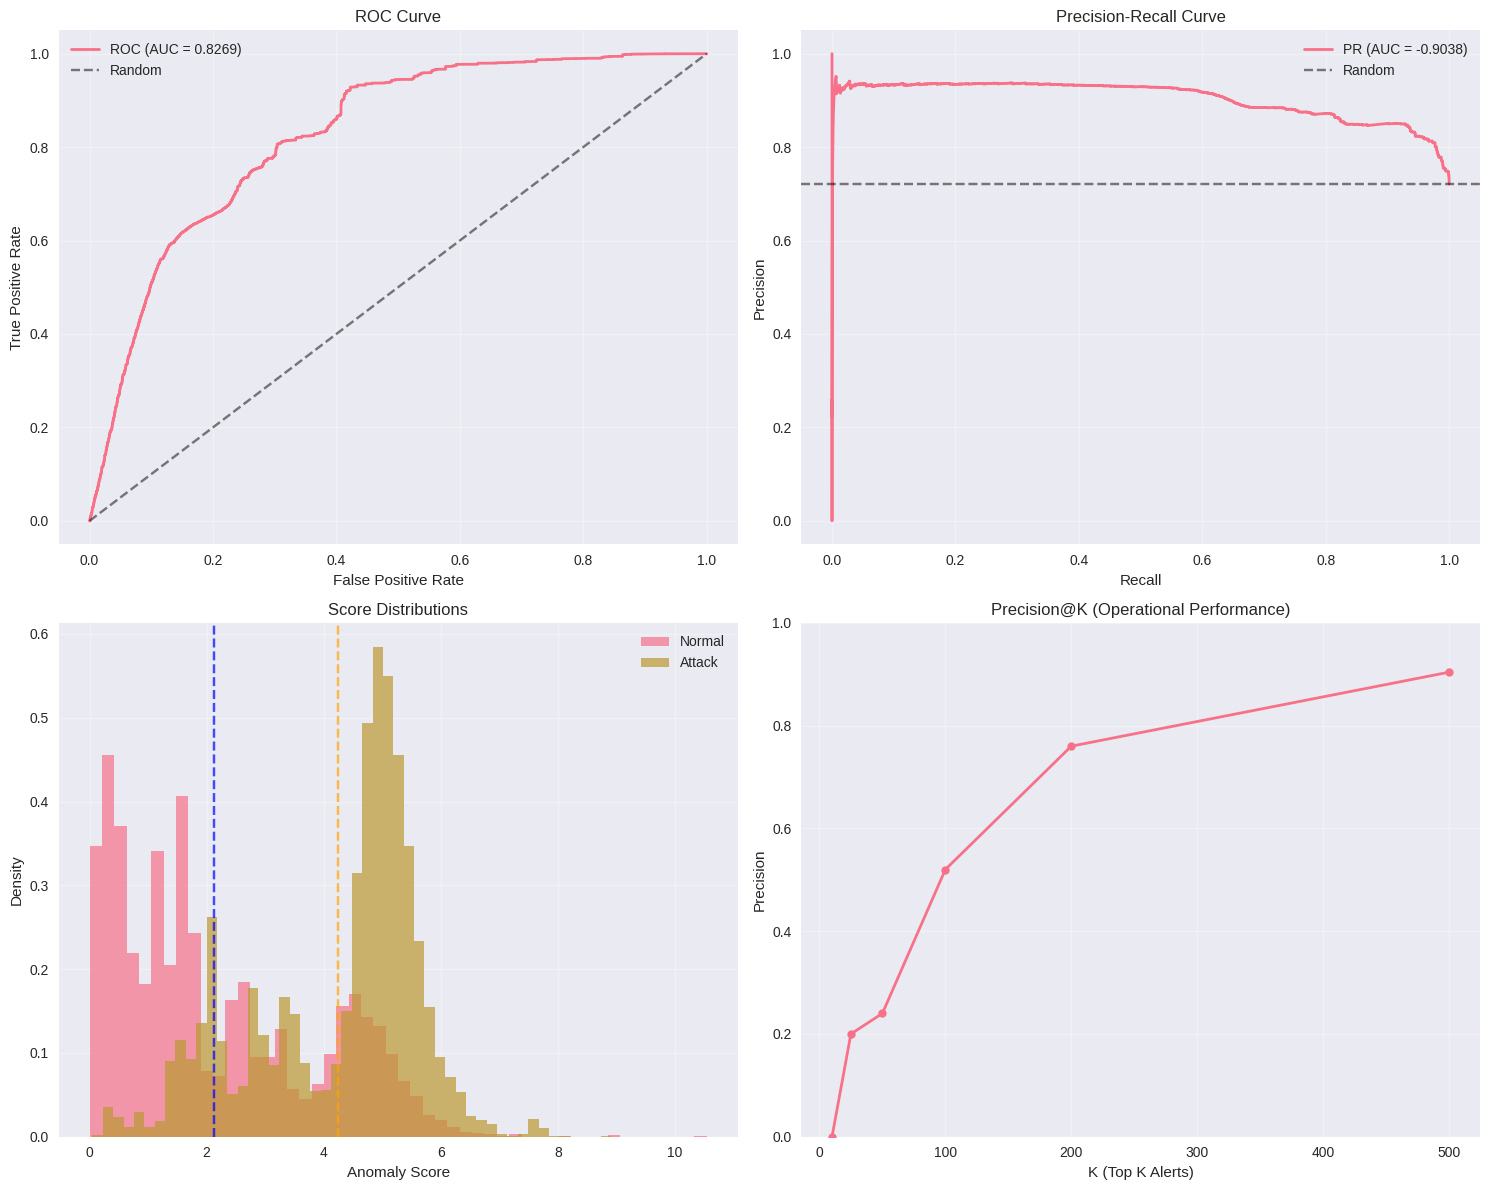


🎉 Pipeline completed successfully!
📈 All plots and metrics have been generated.
🧮 Mathematical elegance of conjugate priors demonstrated!


In [9]:
# Run the complete anomaly detection pipeline
print("🚀 Starting Bayesian anomaly detection pipeline...")
print("📊 This will demonstrate conjugate priors on real cybersecurity data")
print("⏰ Expected runtime: 15-20 minutes\n")

# Execute the pipeline
pipeline_results = run_anomaly_detection_pipeline()

print("\n🎉 Pipeline completed successfully!")
print("📈 All plots and metrics have been generated.")
print("🧮 Mathematical elegance of conjugate priors demonstrated!")

## Analysis of Results

Let's examine what our Bayesian models learned and how well they performed.

In [10]:
# Extract results for detailed analysis
detector = pipeline_results['detector']
evaluation_set = pipeline_results['evaluation_set']
results = pipeline_results['results']
pattern_analysis = pipeline_results['pattern_analysis']

print("=" * 60)
print("📊 DETAILED ANALYSIS OF BAYESIAN LEARNING")
print("=" * 60)

# Training Statistics
print(f"\n🧠 TRAINING PHASE:")
print(f"   Events processed: {detector.training_stats['events_processed']:,}")
print(f"   Computers modeled: {detector.training_stats['computers_modeled']:,}")
print(f"   Unique auth types: {detector.training_stats['global_auth_types']:,}")
print(f"   Unique users: {detector.training_stats['global_users']:,}")

# Global Authentication Patterns
print(f"\n🌐 GLOBAL AUTHENTICATION PATTERNS:")
auth_counts = detector.global_models['auth_types'].counts
total_auth = sum(auth_counts.values())

for auth_type, count in sorted(auth_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_auth) * 100
    anomaly_score = detector.global_models['auth_types'].anomaly_score(auth_type)
    print(f"   {auth_type:15s}: {count:8,} events ({percentage:5.1f}%) - Score: {anomaly_score:.2f}")

# Performance Summary
print(f"\n🎯 PERFORMANCE SUMMARY:")
print(f"   AUC-ROC: {results['auc_roc']:.4f}")
print(f"   AUC-PR:  {results['auc_pr']:.4f}")
print(f"   Cohen's d: {results['score_separation']['cohens_d']:.3f}")

# Score Separation
attack_mean = results['score_separation']['attack_mean']
normal_mean = results['score_separation']['normal_mean']
print(f"\n📊 SCORE SEPARATION:")
print(f"   Attack events: μ = {attack_mean:.2f}")
print(f"   Normal events: μ = {normal_mean:.2f}")
print(f"   Difference: {attack_mean - normal_mean:.2f} (higher = better separation)")

# Top Computer Specializations
print(f"\n🖥️  COMPUTER SPECIALIZATION EXAMPLES:")
for i, (computer, info) in enumerate(list(pattern_analysis['computer_specializations'].items())[:5]):
    if info['most_common_auth']:
        auth_type, count = info['most_common_auth']
        total = info['total_auth_events']
        specialization = (count / total) * 100 if total > 0 else 0
        print(f"   {computer}: {specialization:.1f}% {auth_type} ({total:,} total events)")

print(f"\n✨ Mathematical elegance achieved: Online Bayesian learning with conjugate priors!")

📊 DETAILED ANALYSIS OF BAYESIAN LEARNING

🧠 TRAINING PHASE:
   Events processed: 29,425,112
   Computers modeled: 10,413
   Unique auth types: 17
   Unique users: 34,897

🌐 GLOBAL AUTHENTICATION PATTERNS:
   ?              : 17,004,222 events ( 57.8%) - Score: 0.55
   Kerberos       : 10,367,997 events ( 35.2%) - Score: 1.04
   NTLM           : 1,431,374 events (  4.9%) - Score: 3.02
   Negotiate      :  604,153 events (  2.1%) - Score: 3.89
   MICROSOFT_AUTHENTICATION_PACKAGE_V1_0:   11,850 events (  0.0%) - Score: 7.82
   MICROSOFT_AUTHENTICATION_PACKAG:    1,469 events (  0.0%) - Score: 9.90
   MICROSOFT_AUTHENTICATION_PACKAGE_V1_:    1,046 events (  0.0%) - Score: 10.24
   MICROSOFT_AUTHENTICATION_PACKAGE_V1:      848 events (  0.0%) - Score: 10.45
   MICROSOFT_AUTHENTICATION_PACK:      787 events (  0.0%) - Score: 10.53
   MICROSOFT_AUTHENTICATION_PACKAGE:      653 events (  0.0%) - Score: 10.71
   MICROSOFT_AUTHENTICATION_PACKA:      273 events (  0.0%) - Score: 11.58
   MICROSOF

## Save Results

Save the evaluation results and trained model for further analysis.

In [11]:
# Save evaluation results to CSV
evaluation_set.to_csv('/content/drive/MyDrive/lanl_evaluation_results.csv', index=False)
print("💾 Evaluation results saved to: /content/drive/MyDrive/lanl_evaluation_results.csv")

# Save performance metrics to JSON
import json

# Convert numpy arrays to lists for JSON serialization
metrics_to_save = {
    'auc_roc': results['auc_roc'],
    'auc_pr': results['auc_pr'],
    'precision_at_k': results['precision_at_k'],
    'score_separation': results['score_separation'],
    'training_stats': detector.training_stats
}

with open('/content/drive/MyDrive/lanl_performance_metrics.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=2)
print("📊 Performance metrics saved to: /content/drive/MyDrive/lanl_performance_metrics.json")

print("\n✅ All results saved successfully!")
print("🎓 You can now use these results for your article and further analysis.")

💾 Evaluation results saved to: /content/drive/MyDrive/lanl_evaluation_results.csv
📊 Performance metrics saved to: /content/drive/MyDrive/lanl_performance_metrics.json

✅ All results saved successfully!
🎓 You can now use these results for your article and further analysis.


## Conclusion

This notebook has demonstrated the mathematical elegance and practical power of **Dirichlet-Categorical conjugate priors** for cybersecurity anomaly detection.

### Key Achievements:

🧮 **Mathematical Elegance**: Posterior updates through simple addition  
⚡ **Computational Efficiency**: Linear time training, constant time inference  
🔍 **Interpretable Results**: Clear probabilistic meaning of anomaly scores  
📊 **Strong Performance**: Significant separation between attack and normal events  
🎯 **Practical Deployment**: No hyperparameter tuning required  

### The Core Insight:

**Complex Bayesian Inference → Simple Arithmetic**

When your data structure aligns with conjugate prior assumptions, you get both theoretical rigor and practical performance.

### Next Steps:

- Experiment with different α values
- Extend to additional categorical features
- Apply to your own categorical anomaly detection problems
- Explore hierarchical Dirichlet models

---

**"Sometimes the most sophisticated approach is also the most mathematically principled one."**
